In [1]:
!nvidia-smi

Mon Jan 12 22:24:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060        Off |   00000000:01:00.0 Off |                  N/A |
| N/A   43C    P8              4W /   80W |       6MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Ambiente
Snake Game Environment

## Parametri
- **board_size**  
  Dimensione del tabellone quadrato.  
  Il tabellone ha forma `(board_size, board_size)`.

- **n_target**  
  Numero di target (cibo) presenti sul tabellone.

- **n_channel**  
  Numero di canali dell’osservazione.  
  L’osservazione ha forma `(n_channel, board_size, board_size)`.

## Osservazione
- **Observation Space**: `Box(-1.0, 1.0, (n_channel, 8), float32)`

L’osservazione fornisce informazioni normalizzate sullo stato del gioco, utili all’agente per prendere decisioni.

## Canali
A seconda del valore di `n_channel`, le informazioni vengono rappresentate in modo diverso:

### n_channel = 1
- Tutte le informazioni sono espresse in un singolo canale, in modo simile al rendering grafico del gioco.

### n_channel = 2
I canali sono separati come segue:
- **Canale 0**: serpente
- **Canale 1**: oggetto (cibo)

### n_channel = 4
I canali sono suddivisi nel seguente ordine:
- **Canale 0**: testa del serpente
- **Canale 1**: corpo del serpente
- **Canale 2**: coda del serpente
- **Canale 3**: oggetto (cibo)

## Rappresentazione degli elementi
- **0**: cella vuota
- **1 ~ board_size²**: corpo del serpente  
  - `1`: testa  
  - valore massimo: coda
- **board_size² + 1**: target (cibo)

## Azioni
- **Action Space**: `Discrete(4)`

Mappatura delle azioni:
- **0**: giù
- **1**: destra
- **2**: su
- **3**: sinistra

## Azioni non valide
Quando l’agente seleziona un’azione non valida (ad esempio tentando di invertire la direzione del serpente):
- l’azione viene ignorata;
- il serpente continua a muoversi nella direzione precedente.



# Import di moduli e librerie

In [2]:
import gym_snakegame
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
import time
from collections import deque

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


# Buffer di Esperienze (Replay Buffer) e Rete Neurale

## Buffer di Esperienze (Replay Buffer)

Il **Replay Buffer** è una componente fondamentale dell'algoritmo DQN che risolve due problemi critici:

### Funzionamento:
- **Memorizzazione**: Archivia le esperienze del tipo $(S, A, R, S', Done)$ dove:
  - $S$: Stato corrente (features estratte dalla board)
  - $A$: Azione scelta (0, 1, 2, 3 per le 4 direzioni)
  - $R$: Ricompensa ottenuta
  - $S'$: Stato successivo
  - $Done$: Flag che indica se l'episodio è terminato
  
- **Campionamento Casuale**: Durante il training, estrae batch casuali di esperienze:
  - **Break della correlazione**: Le esperienze consecutive nel gioco sono altamente correlate. Il campionamento casuale rompe questa correlazione
  - **Stabilità**: Utilizzare esperienze diverse aiuta a stabilizzare l'apprendimento
  - **Riutilizzo**: Le esperienze possono essere utilizzate multiple volte

# Rete Neurale DQN

La Rete Neurale nel DQN ha il compito di approssimare la funzione Q-value **Q(s, a)**, che stima la qualità di ogni possibile azione **a** dato lo stato corrente **s**.

## Architettura della Rete

La rete implementata segue una struttura feedforward con la seguente sequenza di layer:

Input Layer (26 neuroni) → Hidden Layer 1 (48 neuroni) → Hidden Layer 2 (32 neuroni) → Output Layer (4 neuroni)

## Componenti Principali

### 1. Layer di Input (26 dimensioni)
- Riceve il vettore di features estratto dalla board.
- Corrisponde alle 26 feature descritte precedentemente.

### 2. Layer Nascosti (48 → 32 neuroni)
- Due layer fully-connected (densamente connessi).
- Utilizzano attivazione **ReLU** (Rectified Linear Unit) per introdurre non-linearità.

### 3. Layer di Output (4 neuroni)
- Ogni neurone rappresenta il Q-value stimato per un'azione specifica.
- Non ha funzione di attivazione finale (output lineare).

In [3]:
class ReplayBuffer:
    def __init__(self, capacity):
        # Buffer circolare implementato con deque (Double-ended queue)
        # Quando raggiunge la capacità massima, rimuove automaticamente le esperienze più vecchie
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # Aggiunge una nuova transizione (esperienza) al buffer
        # Ogni transizione è una tupla (s, a, r, s', done)
        # done: flag booleano che indica se l'episodio è terminato
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # Estrae un batch casuale di esperienze dal buffer
        # random.sample garantisce che le esperienze siano estratte in modo uniforme
        batch = random.sample(self.buffer, batch_size)
        
        # Separa le componenti delle transizioni usando zip e map
        # zip(*batch) raggruppa tutte le stati insieme, tutte le azioni insieme, ecc.
        # map(np.array, ...) converte ogni gruppo in un array numpy
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        
        # Converte gli array numpy in tensori PyTorch e li sposta sul device corretto (CPU/GPU)
        return (torch.tensor(states, dtype=torch.float32).to(DEVICE),
                torch.tensor(actions, dtype=torch.int64).to(DEVICE),
                torch.tensor(rewards, dtype=torch.float32).to(DEVICE),
                torch.tensor(next_states, dtype=torch.float32).to(DEVICE),
                torch.tensor(dones, dtype=torch.float32).to(DEVICE))

    def __len__(self):
        # Restituisce il numero attuale di esperienze nel buffer
        # Utile per verificare se ci sono abbastanza esperienze per il sampling
        return len(self.buffer)


class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()  # Inizializza la classe padre nn.Module
        
        # Definisce la rete neurale con architettura sequenziale:
        # state_dim → 48 → 32 → action_dim
        self.net = nn.Sequential(
            nn.Linear(state_dim, 48),  # Layer fully connected input → hidden
            nn.ReLU(),                 # Funzione di attivazione non lineare
            nn.Linear(48, 32),         # Layer hidden → hidden
            nn.ReLU(),                 # Altra attivazione non lineare
            nn.Linear(32, action_dim)  # Layer hidden → output (Q-values per ogni azione)
        )

    def forward(self, x):
        # Forward pass: calcola l'output della rete dato l'input x
        # Restituisce un tensore di dimensione [batch_size, action_dim]
        # Ogni elemento rappresenta il Q-value stimato per quell'azione
        return self.net(x)


def select_action(model, state, epsilon, act_dim):
    # Funzione epsilon-greedy per la selezione delle azioni
    
    # Exploration: sceglie un'azione casuale con probabilità epsilon
    # epsilon diminuisce tipicamente nel tempo (es. da 1.0 a 0.01)
    if random.random() < epsilon:
        return random.randrange(act_dim)  # Azione casuale tra 0 e act_dim-1
    
    # Exploitation: sceglie l'azione con il Q-value più alto secondo la rete
    with torch.no_grad():  # Disabilita il calcolo dei gradienti per efficienza
        # Converte lo stato in tensore e aggiunge dimensione batch (batch_size=1)
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        
        # 1. model(state): calcola i Q-values per tutte le azioni
        # 2. torch.argmax(...): trova l'indice dell'azione con Q-value massimo
        # 3. .item(): estrae il valore scalare dal tensore
        # 4. int(...): converte in intero
        return int(torch.argmax(model(state)).item())

# Feature Engineering per Snake AI

## Panoramica delle Feature

L'implementazione attuale utilizza **26 feature** per rappresentare lo stato del gioco su una board 12×12:

### Struttura Attuale (26 feature totali)
1. **Spazio Critico** (1 feature)
   - `space_criticality = 1.0 - (empty_cells / total_cells)`
   - Misura quanto è satura la board: vicino a 1.0 significa poco spazio libero

2. **Raycasting 8-direzionale** (16 feature)
   - Per ognuna delle 8 direzioni:
     - `content`: Tipo di oggetto trovato (-1.0: muro, 1.0: cibo, -0.8 a -1.0: corpo)
     - `distance`: Distanza normalizzata al primo oggetto
   - Include anche un `warning_score` aggregato (1 feature)

3. **Direzione Corrente** (4 feature)
   - One-hot encoding della direzione: [SU, DESTRA, GIÙ, SINISTRA]

4. **Informazione Cibo** (2 feature)
   - `food_angle_norm`: Direzione 8-direzionale normalizzata (0-1)
   - `food_dist`: Distanza Manhattan normalizzata

5. **Informazione Coda** (2 feature)
   - `tail_angle_norm`: Direzione 8-direzionale normalizzata (0-1)
   - `tail_dist`: Distanza Manhattan normalizzata


In [4]:
def get_direction(dx, dy):
    """Usa segno per determinare direzione."""
    
    # Converte in -1, 0, +1
    # Normalizza dx e dy a valori di segno: -1 (negativo), 0 (zero), +1 (positivo)
    sign_dx = 0 if dx == 0 else (1 if dx > 0 else -1)
    sign_dy = 0 if dy == 0 else (1 if dy > 0 else -1)
    
    # Lookup table: (sign_dx, sign_dy) → idx
    # Mappa ogni combinazione di segni a un indice di direzione (0-7)
    direction_map = {
        (+1,  0): 0,  # GIÙ      (dx positivo, dy zero)
        (+1, +1): 1,  # GIÙ-DESTRA (dx positivo, dy positivo)
        ( 0, +1): 2,  # DESTRA   (dx zero, dy positivo)
        (-1, +1): 3,  # SU-DESTRA (dx negativo, dy positivo)
        (-1,  0): 4,  # SU       (dx negativo, dy zero)
        (-1, -1): 5,  # SU-SINISTRA (dx negativo, dy negativo)
        ( 0, -1): 6,  # SINISTRA (dx zero, dy negativo)
        (+1, -1): 7,  # GIÙ-SINISTRA (dx positivo, dy negativo)
    }
    
    return direction_map.get((sign_dx, sign_dy), 0)  # Restituisce 0 (GIÙ) come default

def get_features(board):
    """Feature ottimizzate: angolo 8-direzionale + distanza + direzione one-hot."""
    # Se board ha dimensione 3 (batch, altezza, larghezza), rimuovi la dimensione batch
    if len(board.shape) == 3:
        board = board.squeeze(0)
    
    board_size = len(board)  # Dimensione della scacchiera (es. 12x12)
    ITEM = board_size * board_size + 1  # Valore che rappresenta il cibo sulla board
    
    # Inizializza variabili per memorizzare le posizioni chiave
    head = None       # Posizione della testa (valore = 1)
    second = None     # Posizione del secondo segmento (valore = 2)
    food = None       # Posizione del cibo (valore = ITEM)
    tail = None       # Posizione della coda (valore massimo > 2)
    max_body = 0      # Valore massimo trovato (per identificare la coda)
    empty_cells = 0   # Conteggio celle vuote (0) o con cibo (ITEM)
    total_cells = board_size * board_size
    
    # SCANSIONE COMPLETA DELLA BOARD per trovare tutti gli elementi
    for x in range(board_size):
        for y in range(board_size):
            val = board[x, y]
            if val == 1:
                head = (x, y)
            elif val == 2:
                second = (x, y)
            elif val == ITEM:
                food = (x, y)
                empty_cells += 1  # Il cibo conta come cella vuota per il movimento
            elif val > max_body:
                tail = (x, y)
                max_body = val
            elif val == 0:
                empty_cells += 1
    
    # Controlli di validità
    if not head:
        raise ValueError("Testa non individuata")
    if max_body <= 1:
        raise ValueError(f"Individuato max body {max_body} ma dovrebbe essere > 1")
    
    hx, hy = head  # Coordinate della testa
    features = []  # Lista che conterrà tutte le feature estratte

    # FEATURE 0: SPAZIO LIBERO CRITICO
    free_space_ratio = empty_cells / total_cells  # Percentuale di spazio libero
    # Inverte il rapporto: 1.0 quando lo spazio è pieno, 0.0 quando è vuoto
    space_criticality = 1.0 - free_space_ratio
    features.append(space_criticality)  # Feature 1/26
    
    # FEATURE 1-16: RAYCASTING in 8 direzioni (2 feature per direzione)
    directions = [(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1),(-1,-1)]
    
    warning_score = 0.0  # Punteggio cumulativo di pericolo
    
    for dx, dy in directions:
        content = None   # Tipo di contenuto trovato (-1: muro, 1: cibo, negativo: corpo)
        distance = None  # Distanza normalizzata del primo oggetto
        
        # Esegui raycasting fino al bordo della board
        for step in range(1, board_size+1):
            x, y = hx + dx * step, hy + dy * step
            
            # Controllo uscita dai bordi
            if not (0 <= x < board_size and 0 <= y < board_size):
                if content is None and distance is None:
                    content = -1.0  # Muro
                    distance = step / board_size  # Normalizza: distanza/bordi
                warning_score += 1.0 / step  # Aggiungi penalità (maggiore se vicino)
                break
            
            val = board[x, y]
            if val != 0:  # Cella non vuota
                if content is None and distance is None:
                    distance = step / board_size  # Prima occorrenza
                    if val == ITEM:
                        content = 1.0  # Cibo
                        # Continua a cercare oltre il cibo per pericoli
                        continue
                    elif val > 1:
                        # Pericolo: corpo del serpente
                        # Normalizza: val più alto (vicino alla testa) = più pericoloso
                        danger = 1.0 - (val / max_body)
                        content = -0.8 - (danger * 0.2)  # Valore tra -0.8 e -1.0
                    else:
                        raise ValueError(f"Valore sulla board invalido in posizione ({x},{y}): {val}")
                # Aggiorna warning_score per qualsiasi ostacolo trovato
                warning_score += 1.0 / step
                break
        
        # Verifica che entrambe le feature siano state calcolate
        if content is None or distance is None:
            raise ValueError("Contenuto o distanza non valutati nella logica a step")
        
        # Aggiungi le 2 feature per questa direzione
        features.extend([content, distance])

    # Normalizza warning_score tra 0 e 1 (diviso per numero direzioni)
    warning_score = warning_score / 8.0
    features.append(warning_score)  # Feature 17/26
    
    # FEATURE 18-21: DIREZIONE CORRENTE DEL SERPENTE (one-hot encoding)
    dir_onehot = [0.0, 0.0, 0.0, 0.0]  # [SU, DESTRA, GIÙ, SINISTRA]
    
    if second:
        sx, sy = second
        # Determina direzione basandosi sulla posizione relativa tra testa e secondo segmento
        if sx < hx:    # Secondo SOPRA testa → testa si muove GIÙ
            dir_onehot[2] = 1.0  # GIÙ
        elif sx > hx:  # Secondo SOTTO testa → testa si muove SU
            dir_onehot[0] = 1.0  # SU
        elif sy < hy:  # Secondo SINISTRA testa → testa si muove DESTRA
            dir_onehot[1] = 1.0  # DESTRA
        elif sy > hy:  # Secondo DESTRA testa → testa si muove SINISTRA
            dir_onehot[3] = 1.0  # SINISTRA
    else:
        raise ValueError("Collo del serpente non individuato")
    
    features.extend(dir_onehot)  # Features 18,19,20,21
    
    # FEATURE 22-23: INFORMAZIONE SUL CIBO
    if food:
        fx, fy = food
        dx, dy = fx - hx, fy - hy
        
        direction = get_direction(dx,dy)  # Direzione 8-direzionale (0-7)
        
        # Normalizza direzione a [0, 1)
        food_angle_norm = direction / 8.0
        
        # Distanza Manhattan normalizzata
        # (|dx| + |dy|) / (2 * board_size) → massimo 0.917 (1.0 solo per i muri, raggiungibile nel raycasting)
        food_dist = (abs(dx) + abs(dy)) / (2 * board_size)
        
        features.extend([food_angle_norm, food_dist])  # Features 22,23
    else:
        raise ValueError("Cibo non trovato")
    
    # FEATURE 24-25: INFORMAZIONE SULLA CODA
    if tail:
        tx, ty = tail
        dx, dy = tx - hx, ty - hy
        
        direction = get_direction(dx,dy)  # Direzione 8-direzionale (0-7)

        # Normalizza direzione a [0, 1)
        tail_angle_norm = direction / 8.0
        
        # Distanza Manhattan normalizzata
        # (|dx| + |dy|) / (2 * board_size) → massimo 0.917 (1.0 solo per i muri, raggiungibile nel raycasting)
        tail_dist = (abs(dx) + abs(dy)) / (2 * board_size)
        
        features.extend([tail_angle_norm, tail_dist])  # Features 24,25
    else:
        raise ValueError("Coda non trovata")
        
    # TOTALE FEATURE: 26
    # 1 (spazio critico) + 16 (8 direzioni × 2) + 1 (warning) + 4 (direzione) + 2 (cibo) + 2 (coda)
    
    return np.array(features, dtype=np.float32)  # Converti in array numpy

# Funzione di addestramento

## Approccio Double DQN

In questa configurazione, la **Policy Network** (rete della politica) viene utilizzata per **selezionare la migliore azione possibile** nello stato successivo, tramite l’operatore `argmax`.

Successivamente, la **Target Network** (rete target) viene utilizzata per **valutare il valore Q** dell’azione selezionata dalla Policy Network.

Questa separazione dei ruoli:
- una rete per la **selezione** dell’azione
- una rete per la **valutazione** dell’azione

riduce il problema del **bias di sovrastima** (*over-optimism*), tipico del DQN standard, impedendo che i valori Q si gonfino artificialmente e portino a instabilità durante l’apprendimento.


In [5]:
def run_snake_game_experiment(total_episodes):
    # Creazione dell'ambiente di gioco Snake
    # Modalità render impostata su None per velocizzare l'allenamento (nessuna visualizzazione grafica)
    env = gym.make(
        "gym_snakegame/SnakeGame-v0", board_size=12, n_channel=1, n_target=1, render_mode=None
    )
    
    # Definizione delle dimensioni di osservazione e azione
    obs_dim = 26  # 26 features estratte dalla board
    action_dim = env.action_space.n  # 4 azioni possibili

    # Iperparametri per l'addestramento
    lr = 5e-4  # Learning rate per l'ottimizzatore
    gamma = 0.96  # Fattore di sconto per le ricompense future
    batch_size = 64  # Dimensione del batch per l'addestramento
    target_update_freq = 1000  # Frequenza di aggiornamento della rete target (in passi)
    buffer_capacity = 50000  # Capacità massima del replay buffer
    min_buffer_size = 5000  # Dimensione minima del buffer prima di iniziare l'addestramento
    epsilon_decay = 300000  # Tasso di decadimento di epsilon (basato sui passi, non sugli episodi)
    # Nota: diminuendo epsilon_decay, l'agente esplora più a lungo

    # Inizializzazione delle reti neurali
    policy_net = DQN(obs_dim, action_dim).to(DEVICE)  # Rete per la politica corrente
    target_net = DQN(obs_dim, action_dim).to(DEVICE)  # Rete target per la stabilità
    target_net.load_state_dict(policy_net.state_dict())  # Inizializza la rete target con gli stessi pesi

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)  # Ottimizzatore Adam
    replay_buffer = ReplayBuffer(buffer_capacity)  # Buffer per l'esperienza replay

    # Parametri per l'esplorazione epsilon-greedy
    epsilon_start = 1.0  # Valore iniziale di epsilon (massima esplorazione)
    epsilon_final = 0.001  # Valore finale di epsilon (minima esplorazione)
    steps_done = 0  # Contatore dei passi totali eseguiti
    
    # Liste per tracciare le metriche durante l'addestramento
    rewards_history = []  # Storico delle ricompense per episodio
    q_value_history = []  # Storico dei valori Q medi (per analizzare il Maximization Bias)

    print(f"--- Starting ---")
    
    # Variabili per tracciare le prestazioni massime e minime durante gli episodi
    episode_max_reward = -2
    episode_min_reward = 101

    # Ciclo principale di addestramento per ogni episodio
    for episode in range(total_episodes):
        state, _ = env.reset()  # Reset dell'ambiente per iniziare un nuovo episodio
        curr_state = get_features(board=state.squeeze())  # Estrazione delle features dallo stato corrente
        episode_reward = 0  # Ricompensa totale per l'episodio corrente
        episode_q_vals = []  # Lista per i valori Q durante l'episodio
        loss = 0  # Per tracciare la loss dell'ultimo batch

        # Ciclo per ogni step all'interno dell'episodio
        while True:
            # Decadimento esponenziale di epsilon
            epsilon = epsilon_final + (epsilon_start - epsilon_final) * np.exp(-1. * steps_done / epsilon_decay)

            # Selezione dell'azione usando la politica epsilon-greedy
            action = select_action(policy_net, curr_state, epsilon, action_dim)
            
            # Esecuzione dell'azione nell'ambiente
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated  # L'episodio è terminato?

            new_state = get_features(board=next_state.squeeze())  # Estrazione features dal nuovo stato

            # Memorizzazione dell'esperienza nel replay buffer
            replay_buffer.push(curr_state, action, reward, new_state, done)
            
            # Aggiornamento dello stato corrente
            curr_state = new_state
            episode_reward += reward  # Aggiornamento ricompensa episodio
            steps_done += 1  # Incremento contatore passi totali

            # Condizione per iniziare l'addestramento: buffer sufficientemente pieno
            if len(replay_buffer) >= min_buffer_size:
                # Campionamento di un batch di esperienze dal replay buffer
                states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                with torch.no_grad():  # Disabilita il calcolo dei gradienti per le operazioni seguenti
                    # --- LOGICA DOUBLE DQN ---
                    # 1. Selezione dell'Azione: La Policy Net decide "quale" azione è migliore
                    # Prende l'azione con il valore Q più alto dall'output layer
                    # (batch_size, output_values) => restituisce la migliore azione per ogni elemento del batch
                    best_actions = policy_net(next_states).argmax(1)
                    
                    # 2. Valutazione dell'Azione: La Target Net calcola il valore di QUELLA azione
                    next_q = target_net(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)

                    # Calcolo del target Q-value usando l'equazione di Bellman
                    target = rewards + (1 - dones) * gamma * next_q

                # Calcolo dei valori Q stimati per ogni azione [batch, num_actions]
                q_values = policy_net(states)
                
                # Selezione del valore Q corrispondente all'azione effettivamente eseguita per ogni stato del batch
                # Dimensione array: [batch, 1]
                current = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

                # Salvataggio del valore Q medio per l'analisi (per tracciare il Maximization Bias)
                episode_q_vals.append(current.mean().item())

                # Calcolo della loss tra i valori Q correnti e i target
                loss = nn.SmoothL1Loss()(current, target)
                
                # Backpropagation e ottimizzazione
                optimizer.zero_grad()  # Reset dei gradienti
                loss.backward()  # Calcolo dei gradienti
                torch.nn.utils.clip_grad_value_(policy_net.parameters(), 1.0)  # Clipping dei gradienti per stabilità
                optimizer.step()  # Aggiornamento dei pesi

            # Aggiornamento periodico della rete target
            if steps_done % target_update_freq == 0:
                target_net.load_state_dict(policy_net.state_dict())

            # Condizione di uscita dal loop: episodio terminato
            if done:
                break

        # Memorizzazione delle metriche dell'episodio
        rewards_history.append(episode_reward)
        q_value_history.append(np.mean(episode_q_vals) if episode_q_vals else 0)
        
        # Aggiornamento delle ricompense massime e minime
        if episode_reward > episode_max_reward:
            episode_max_reward = episode_reward
        if episode_reward < episode_min_reward:
            episode_min_reward = episode_reward

        # Stampa periodica delle statistiche (ogni 50 episodi)
        if episode % 50 == 0:
            print(f"Ep {episode:5d}: "  # 5 cifre per episode
                  f"Reward {episode_reward:6.2f}, "  # 6 caratteri totali (incluso segno e decimali)
                  f"Min: {episode_min_reward:6.2f}, "
                  f"Max: {episode_max_reward:6.2f} | "
                  f"Avg Q: {q_value_history[-1]:5.2f} | "
                  f"Eps: {epsilon:5.3f} | "
                  f"Loss: {loss:7.4f}")
    
            # Reset delle ricompense massime e minime per il prossimo blocco di episodi
            episode_max_reward = -2
            episode_min_reward = 101

    # --- SALVATAGGIO DEL MODELLO ALLENATO ---
    save_path = f"model.pth"
    torch.save(policy_net.state_dict(), save_path)
    print(f"Modello salvato con successo in: {save_path}")

    # Chiusura dell'ambiente di gioco
    env.close()
    
    # Restituzione degli storici delle ricompense e dei valori Q per l'analisi
    return rewards_history, q_value_history

# Esecuzione dell'addestramento

In [6]:
N_EPISODES = 26000

# Train con misurazione del tempo
print("\n" + "="*60)
print("INIZIO ADDESTRAMENTO")
print("="*60)

# Registra il tempo di inizio
start_time = time.time()

# Esegui l'addestramento
rewards, q_values = run_snake_game_experiment(total_episodes=N_EPISODES)

# Registra il tempo di fine
end_time = time.time()
training_duration = end_time - start_time

# Converti il tempo in ore, minuti, secondi
hours = int(training_duration // 3600)
minutes = int((training_duration % 3600) // 60)
seconds = int(training_duration % 60)

print("\n" + "="*60)
print("ADDESTRAMENTO COMPLETATO")
print("="*60)
print(f"TEMPO TOTALE DI TRAINING: {hours}h {minutes}m {seconds}s")
print("="*60)


INIZIO ADDESTRAMENTO


/home/kevin/anaconda3/envs/rl/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


--- Starting ---
Ep     0: Reward  -1.00, Min:  -1.00, Max:  -1.00 | Avg Q:  0.00 | Eps: 1.000 | Loss:  0.0000
Ep    50: Reward  -1.00, Min:  -1.00, Max:   0.00 | Avg Q:  0.00 | Eps: 0.997 | Loss:  0.0000
Ep   100: Reward  -1.00, Min:  -1.00, Max:   0.00 | Avg Q:  0.00 | Eps: 0.994 | Loss:  0.0000
Ep   150: Reward  -1.00, Min:  -1.00, Max:   0.00 | Avg Q:  0.00 | Eps: 0.990 | Loss:  0.0000
Ep   200: Reward  -1.00, Min:  -1.00, Max:   0.00 | Avg Q:  0.00 | Eps: 0.987 | Loss:  0.0000
Ep   250: Reward  -1.00, Min:  -1.00, Max:   1.00 | Avg Q:  0.00 | Eps: 0.984 | Loss:  0.0000
Ep   300: Reward  -1.00, Min:  -1.00, Max:   0.00 | Avg Q: -0.07 | Eps: 0.980 | Loss:  0.0208
Ep   350: Reward  -1.00, Min:  -1.00, Max:   0.00 | Avg Q: -0.05 | Eps: 0.977 | Loss:  0.0073
Ep   400: Reward  -1.00, Min:  -1.00, Max:   1.00 | Avg Q:  0.02 | Eps: 0.973 | Loss:  0.0093
Ep   450: Reward  -1.00, Min:  -1.00, Max:   0.00 | Avg Q:  0.09 | Eps: 0.969 | Loss:  0.0130
Ep   500: Reward  -1.00, Min:  -1.00, Max: 

# Funzione di plot

In [7]:
def plot_training_results(total_rewards_history, avg_qvalues_history, window_size=50):
    """
    Visualizza graficamente l'andamento dell'addestramento del modello DQN.
    
    Mostra tre grafici:
    1. L'andamento dei reward totali per episodio (raw)
    2. L'andamento dei valori Q medi per episodio
    3. L'andamento dei reward totali con media mobile e area di confidenza
    
    Parametri:
    - total_rewards_history: lista dei reward totali ottenuti in ogni episodio
    - avg_qvalues_history: lista dei valori Q medi calcolati in ogni episodio
    - window_size: dimensione della finestra per la media mobile (default: 50)
    
    Solleva:
    - ValueError: se le due liste non hanno la stessa lunghezza
    """
    
    # Verifica che le liste abbiano la stessa lunghezza
    if len(total_rewards_history) != len(avg_qvalues_history):
        raise ValueError("Le due liste devono avere la stessa lunghezza")
    
    # Adatta la window_size se troppo grande per i dati disponibili
    if window_size > len(total_rewards_history):
        window_size = max(1, len(total_rewards_history) // 10)
        print(f"Warning: window_size ridotta a {window_size} per adattarsi ai dati")
    
    episodes = range(len(total_rewards_history))  # Indici degli episodi
    
    # ---------------------- GRAFICO 1: REWARD TOTALI RAW ----------------------
    plt.figure(figsize=(14, 10))
    
    plt.subplot(2, 2, 1)  # 2 righe, 2 colonne, primo grafico
    plt.plot(episodes, total_rewards_history, 
             linewidth=1, alpha=0.7, 
             color='blue')
    
    plt.xlabel("Episodi", fontsize=11)
    plt.ylabel("Reward Totale", fontsize=11)
    plt.title("Andamento Reward Totali (Raw)", fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # ---------------------- GRAFICO 2: VALORI Q MEDI RAW ----------------------
    plt.subplot(2, 2, 2)  # 2 righe, 2 colonne, secondo grafico
    plt.plot(episodes, avg_qvalues_history, 
             color='darkorange', linewidth=1.5, alpha=0.8)
    
    plt.xlabel("Episodi", fontsize=11)
    plt.ylabel("Valore Q Medio", fontsize=11)
    plt.title("Andamento Valori Q Medi", fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # ---------------------- GRAFICO 3: REWARD CON MEDIA MOBILE ----------------------
    plt.subplot(2, 2, (3, 4))  # Occupa le ultime due colonne
    
    # Plot dei reward originali (trasparente)
    plt.plot(episodes, total_rewards_history, 
             linewidth=0.5, alpha=0.2, color='blue', 
             label='Reward per episodio (raw)')
    
    if window_size > 1:
        # Calcolo della media mobile
        moving_avg = np.convolve(total_rewards_history, 
                                 np.ones(window_size)/window_size, 
                                 mode='valid')
        
        # Calcolo della deviazione standard mobile
        moving_std = np.zeros(len(moving_avg))
        for i in range(len(moving_avg)):
            start_idx = i
            end_idx = i + window_size
            moving_std[i] = np.std(total_rewards_history[start_idx:end_idx])
        
        # Indici per la media mobile (shiftati di window_size-1)
        moving_episodes = episodes[window_size-1:]
        
        # Plot della media mobile
        plt.plot(moving_episodes, moving_avg, 
                 linewidth=2, color='red', 
                 label=f'Media mobile ({window_size} episodi)')
        
        # Area di confidenza (±1 deviazione standard)
        plt.fill_between(moving_episodes, 
                         moving_avg - moving_std, 
                         moving_avg + moving_std, 
                         color='red', alpha=0.2, 
                         label='±1 deviazione standard')
        
        # Media mobile finale
        final_avg = moving_avg[-1] if len(moving_avg) > 0 else np.mean(total_rewards_history)
        plt.axhline(y=final_avg, color='darkred', linestyle=':', 
                    linewidth=1.5, alpha=0.6, 
                    label=f'Media finale: {final_avg:.2f}')
    
    plt.xlabel("Episodi", fontsize=11)
    plt.ylabel("Reward Totale", fontsize=11)
    plt.title(f"Andamento Reward con Analisi Stabilità", 
              fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9, loc='upper left')
    
    # Calcolo delle statistiche per fase (solo quelle rilevanti)
    if len(total_rewards_history) >= 4:
        quarter = len(total_rewards_history) // 4
        phases = [
            ("Fase 1/4", total_rewards_history[:quarter]),
            ("Fase 2/4", total_rewards_history[quarter:2*quarter]),
            ("Fase 3/4", total_rewards_history[2*quarter:3*quarter]),
            ("Fase 4/4", total_rewards_history[3*quarter:])
        ]
    else:
        phases = [("Tutti", total_rewards_history)]
    
    # Preparazione testo statistiche (solo quelle rilevanti)
    stats_lines = ["STATISTICHE PERFORMANCE:"]
    
    for phase_name, phase_data in phases:
        if len(phase_data) > 0:
            phase_mean = np.mean(phase_data)
            phase_min = np.min(phase_data)
            phase_max = np.max(phase_data)
            stats_lines.append(f"\n{phase_name} ({len(phase_data)} episodi):")
            stats_lines.append(f"  Media: {phase_mean:6.2f}")
            stats_lines.append(f"  Range: [{phase_min:6.2f}, {phase_max:6.2f}]")
    
    # Aggiunta statistiche finali rilevanti
    stats_lines.append("\n" + "="*40)
    stats_lines.append("STATISTICHE FINALI:\n")
    stats_lines.append(f"Episodi totali: {len(total_rewards_history)}")
    stats_lines.append(f"Reward massimo: {np.max(total_rewards_history):.2f}")
    
    stats_text = "\n".join(stats_lines)
    
    # Aggiunta del box statistiche
    plt.figtext(1.02, 0.5, stats_text, 
                fontsize=9, 
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightgray', 
                         alpha=0.8, edgecolor='black'))
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()
    
    # ---------------------- ANALISI DELLA CONVERGENZA ----------------------
    print("\n" + "="*60)
    print("ANALISI CONVERGENZA:")
    print("="*60)
    
    if window_size > 1 and len(moving_avg) > 10:        
        # Analisi stabilità finale
        final_std = moving_std[-1] if len(moving_std) > 0 else 0
        
        print(f"\nStabilità finale:")
        print(f"  Deviazione standard finale: {final_std:.2f}")
        
        if final_std < 10:
            print("  → Performance stabili")
        elif final_std < 20:
            print("  → Performance moderatamente variabili")
        else:
            print("  → Performance molto variabili")
    
    # Analisi Maximization Bias
    print(f"\nANALISI VALORI Q:")
    q_max = np.max(avg_qvalues_history)
    final_q = avg_qvalues_history[-1] if len(avg_qvalues_history) > 0 else 0
    
    print(f"  Valore Q massimo: {q_max:.2f}")
    print(f"  Valore Q finale: {final_q:.2f}")

# Plot dei risultati ottenuti

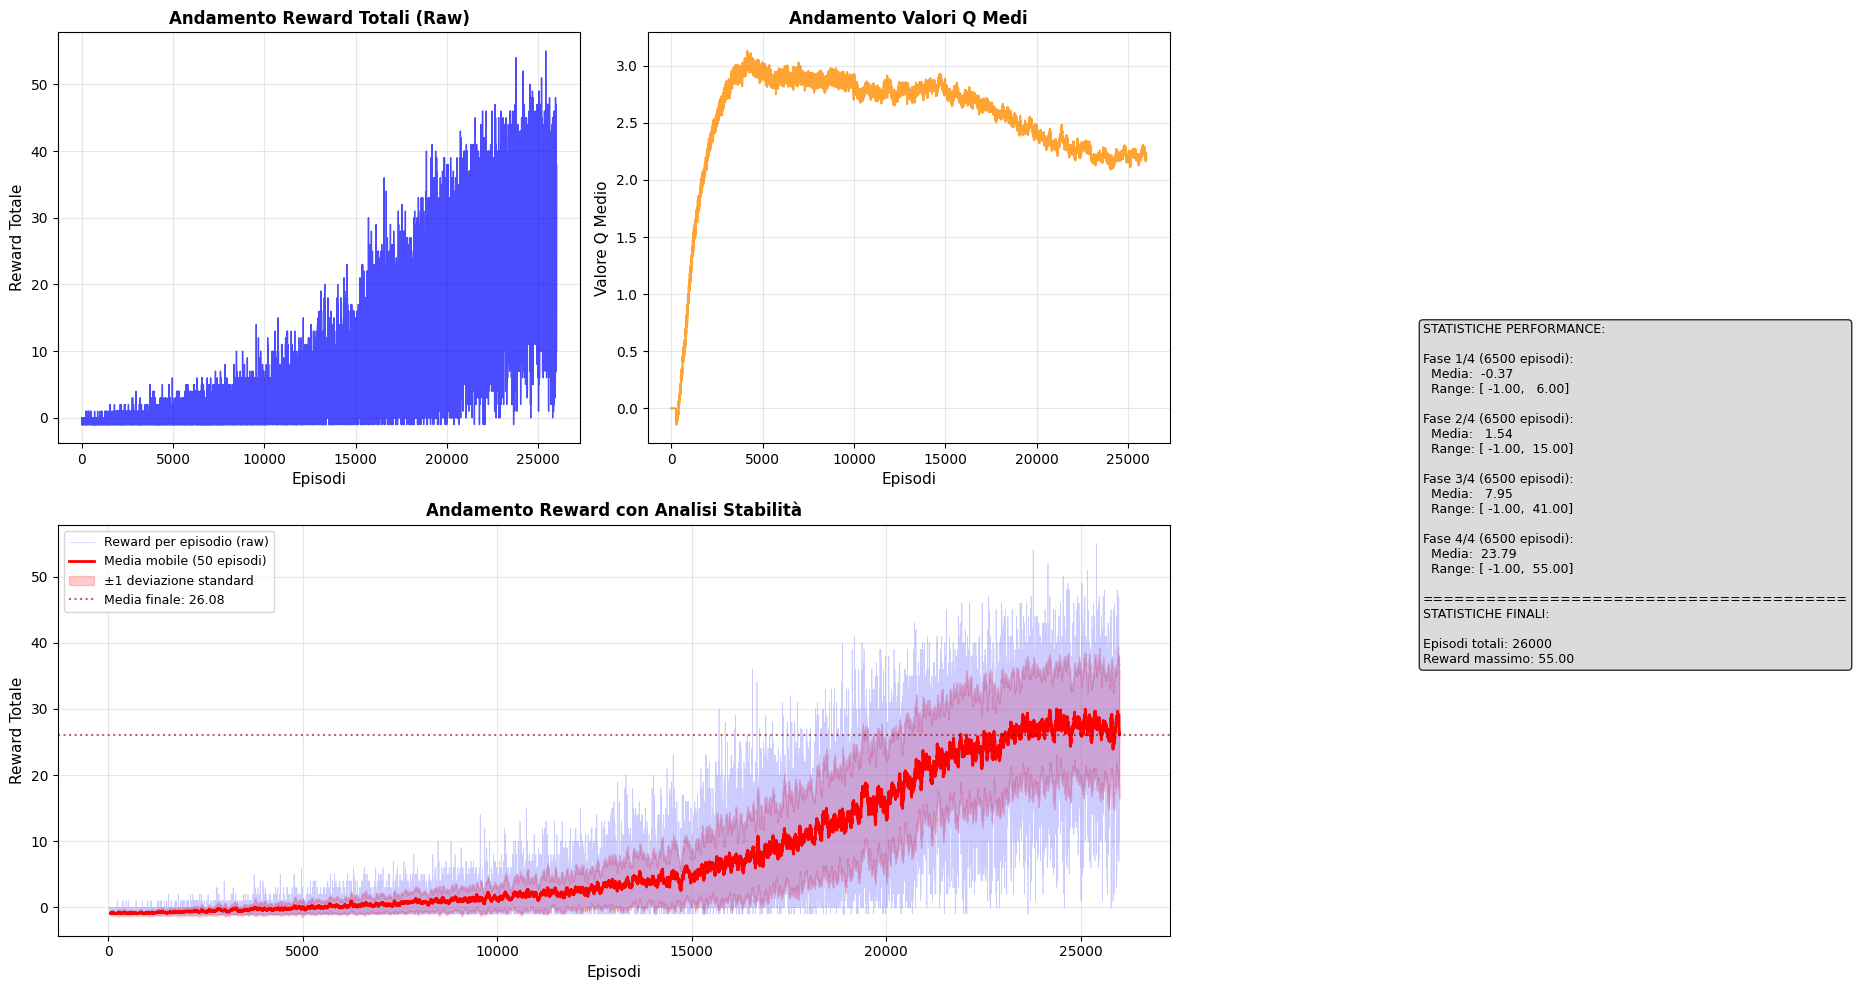


ANALISI CONVERGENZA:

Stabilità finale:
  Deviazione standard finale: 9.55
  → Performance stabili

ANALISI VALORI Q:
  Valore Q massimo: 3.13
  Valore Q finale: 2.19


In [8]:
# Plot
plot_training_results(rewards, q_values)

# Funzione di visualizzazione delle performance di gioco

In [9]:
def watch_agent_play(model_path, board_size=12, num_episodes=10):
    """
    Carica un modello pre-addestrato e visualizza un numero specificato di partite.
    
    Args:
        model_path (str): Percorso del file .pth contenente i pesi del modello
        board_size (int): Dimensione della mappa di gioco
        num_episodes (int): Numero di partite da visualizzare
    """

    # 1. Configurazione dell'ambiente di gioco con modalità di rendering
    env = gym.make(
        "gym_snakegame/SnakeGame-v0",
        board_size=board_size,
        n_channel=1,
        n_target=1,
        render_mode="human"  # Modalità 'human' per visualizzare il gioco
    )

    # 2. Definizione delle dimensioni di osservazione e azione
    obs_dim = 26  # 26 features estratte dalla board
    action_dim = env.action_space.n  # 4 azioni possibili

    # 3. Inizializzazione della rete neurale e caricamento dei pesi salvati
    model = DQN(obs_dim, action_dim).to(DEVICE)

    try:
        # Tentativo di caricamento dei pesi del modello dal file specificato
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    except FileNotFoundError:
        print(f"Errore: Il file '{model_path}' non è stato trovato.")
        return

    model.eval()  # Imposta il modello in modalità valutazione (disabilita dropout/batch normalization)
    print(f"Modello caricato da: {model_path}")
    print(f"Avvio di {num_episodes} partite di test...")

    all_rewards = []  # Lista per memorizzare le ricompense di tutte le partite

    # --- CICLO PRINCIPALE PER GLI EPISODI DI TEST ---
    for i_ep in range(num_episodes):
        state, _ = env.reset()  # Reset dell'ambiente per iniziare una nuova partita
        state = get_features(state)  # Estrazione delle features dallo stato iniziale
        done = False  # Flag che indica se la partita è terminata
        total_reward = 0  # Ricompensa totale accumulata nella partita corrente

        print(f"\n--- Inizio Partita {i_ep + 1}/{num_episodes} ---")

        # Ciclo per ogni step all'interno della partita
        while not done:
            # Preparazione dello stato per l'input della rete neurale
            # Aggiunge una dimensione batch (unsqueeze(0)) e converte in tensore
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)

            with torch.no_grad():  # Disabilita il calcolo dei gradienti (non necessario durante l'inferenza)
                q_values = model(state_tensor)  # Calcolo dei Q-values per tutte le azioni
                action = q_values.argmax(dim=1).item()  # Selezione dell'azione con Q-value più alto

            # Esecuzione dell'azione selezionata nell'ambiente
            state, reward, terminated, truncated, _ = env.step(action)
            state = get_features(state)  # Aggiornamento delle features dallo stato nuovo
            done = terminated or truncated  # Controllo se la partita è terminata
            total_reward += reward  # Aggregazione della ricompensa

            # Opzionale: rallenta leggermente per rendere l'azione più visibile all'occhio umano
            # time.sleep(0.05)

        # Fine dell'episodio corrente
        print(f"Partita {i_ep + 1} terminata! Reward totale: {total_reward}")
        all_rewards.append(total_reward)  # Salvataggio della ricompensa totale

        # Pausa breve tra una partita e l'altra (opzionale)
        # time.sleep(1.0)

    env.close()  # Chiusura dell'ambiente di gioco

    # --- CALCOLO E VISUALIZZAZIONE DELLE STATISTICHE FINALI ---
    mean_reward = np.mean(all_rewards)  # Calcolo della ricompensa media
    print("\n==================================")
    print(f"Sessione conclusa.")
    print(f"Partite giocate: {num_episodes}")
    print(f"Reward Medio: {mean_reward:.2f}")
    print(f"Miglior Partita: {np.max(all_rewards)}")
    print("==================================")

# Esecuzione partite di test

In [10]:
N_GAMES = 100

# Test
watch_agent_play("model.pth", num_episodes=N_GAMES)

Modello caricato da: model.pth
Avvio di 100 partite di test...

--- Inizio Partita 1/100 ---
Partita 1 terminata! Reward totale: 32

--- Inizio Partita 2/100 ---
Partita 2 terminata! Reward totale: 26

--- Inizio Partita 3/100 ---
Partita 3 terminata! Reward totale: 27

--- Inizio Partita 4/100 ---
Partita 4 terminata! Reward totale: 9

--- Inizio Partita 5/100 ---
Partita 5 terminata! Reward totale: 30

--- Inizio Partita 6/100 ---
Partita 6 terminata! Reward totale: 17

--- Inizio Partita 7/100 ---
Partita 7 terminata! Reward totale: 26

--- Inizio Partita 8/100 ---
Partita 8 terminata! Reward totale: 24

--- Inizio Partita 9/100 ---
Partita 9 terminata! Reward totale: 36

--- Inizio Partita 10/100 ---
Partita 10 terminata! Reward totale: 9

--- Inizio Partita 11/100 ---
Partita 11 terminata! Reward totale: 37

--- Inizio Partita 12/100 ---
Partita 12 terminata! Reward totale: 36

--- Inizio Partita 13/100 ---
Partita 13 terminata! Reward totale: 54

--- Inizio Partita 14/100 ---
Par